## <span style="color:green"> Home Task </span>

### <span style="color:green"> Brest cancer dataset </span>

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X, y, labels, features = cancer.data, cancer.target, cancer.target_names, cancer.feature_names
print ('labels:',labels)
print ('features:', features)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

labels: ['malignant' 'benign']
features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


### <span style="color:green"> Brest cancer dataset </span>

train accuracy= 97.653%
test accuracy= 95.105%


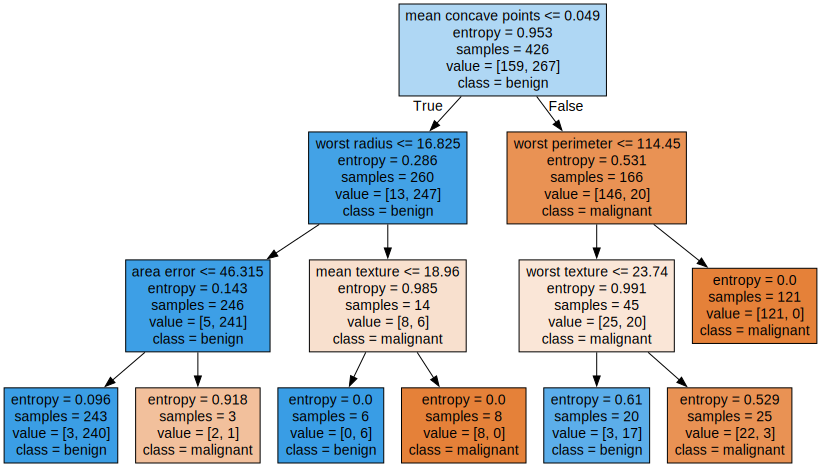

In [15]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import graphviz

clf = DecisionTreeClassifier(
    criterion = 'entropy',
    random_state=20,
    max_depth = 3
).fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))
graph_viz = tree.export_graphviz(clf, out_file=None,feature_names=features, class_names=labels, filled = True)
graph = graphviz.Source(graph_viz)
# graph.view(cleanup =True) # cleanup (bool) – Delete the source file after rendering.
display(graph)

### <span style="color:green"> RandomForest </span>

In [16]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    random_state = 0
).fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 97.203%


### <span style="color:green"> Gradient Boosting Decision Trees (GBDT) </span>

In [17]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(
    learning_rate = 0.01,
    max_depth = 3
).fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 98.826%
test accuracy= 95.804%


### <span style="color:green"> XGBoost </span>

In [18]:
# YOUR_CODE.  create the classifier and train it 
# START_CODE 
from xgboost import XGBClassifier

clf = XGBClassifier(
    eval_metric='logloss'
).fit(X_train, y_train)
# END_CODE 

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 98.601%


## Additional tasks 

### 1) Binary Classification: 

* Task: Train an XGBClassifier to predict whether a person's income exceeds $50,000 per year based on census data (age, education, occupation, etc.).

In [19]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from sklearn.preprocessing  import LabelEncoder 
from sklearn.metrics import accuracy_score, classification_report

from sklearn.datasets import fetch_openml

In [20]:
# Load datasets fetch_openml, income_person

data_class = fetch_openml(name ='adult', version=2, as_frame=True)
df_income = data_class.frame
df_income

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [21]:
# split data by target and features 

y = df_income['class'].replace({'<=50K': 0, '>50K': 1})
X = df_income.drop(columns = 'class')

print(f"X.shape: {X.shape}")
print(f"X.shape: {y.shape}")
 

X.shape: (48842, 14)
X.shape: (48842,)


C:\Users\Admin\AppData\Local\Temp\ipykernel_18584\386221229.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df_income['class'].replace({'<=50K': 0, '>50K': 1})
C:\Users\Admin\AppData\Local\Temp\ipykernel_18584\386221229.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  y = df_income['class'].replace({'<=50K': 0, '>50K': 1})


In [22]:
# split data by train and test datasets

X_train, X_test, y_train, y_test = train_test_split(
            X, y, random_state=20 ) 

print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape) 

print ('features:', data_class.feature_names)
dict_names = {i:v for i,v in enumerate(df_income["class"].unique())}
print ('target names :', dict_names)

X_train.shape=  (36631, 14)
X_test.shape=  (12211, 14)
y_train.shape=  (36631,)
y_test.shape=  (12211,)
features: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']
target names : {0: '<=50K', 1: '>50K'}


In [23]:
# Encoder - handling categorical values

# choose only columns with string type 
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
print(f"\nNumbers columns with text data: {len(categorical_cols)}")
 

for col in categorical_cols:
    # save categorical data in train dataset
    known_categories = set(X_train[col].unique())
    most_common = X_train[col].mode()[0]

    # replace the unknowns columns in the test
    X_test[col] = X_test[col].apply(
        lambda x: x if x in known_categories else most_common
    )
     
    # encoder data
    le = LabelEncoder() 
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
            


    # print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")
 
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
  



Numbers columns with text data: 8
X_train shape: (36631, 14)
y_train shape: (36631,)


In [24]:
# Learning XGBClassifier model 

clf = XGBClassifier( 
    eval_metric='logloss',
).fit(X_train, y_train)
print("Result:")
print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))
 
# Output result predict on the test set
y_pred = clf.predict(X_test)

print(f"\naccuracy: {accuracy_score(y_test, y_pred)* 100:.2f}%")
print("\nclassification_report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))


Result:
train accuracy= 90.415%
test accuracy= 87.216%

accuracy: 87.22%

classification_report:
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      9228
        >50K       0.78      0.66      0.72      2983

    accuracy                           0.87     12211
   macro avg       0.84      0.80      0.82     12211
weighted avg       0.87      0.87      0.87     12211



### 2) Regression: 

* Task: Train an XGBRegressor to predict the final sale price of houses in Ames, Iowa, based on various features (area, quality, year built).

In [25]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor  
from sklearn.model_selection import train_test_split

from sklearn.preprocessing  import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.datasets import fetch_openml

In [26]:
# Load datasets fetch_openml, house_prices

data_reg = fetch_openml(name='house_prices', version=1, as_frame=True)
df_house = data_reg.frame
df_house


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [27]:
# split data by target and features 

X = df_house.drop(columns=['SalePrice', 'Id']) 
y = df_house['SalePrice']

print(f"X.shape: {X.shape}")
print(f"X.shape: {y.shape}")
 

X.shape: (1460, 79)
X.shape: (1460,)


In [28]:
# split data by train and test datasets

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

print ('X_train.shape= ',X_train.shape)
print ('X_test.shape= ',X_test.shape)
print ('y_train.shape= ',y_train.shape)
print ('y_test.shape= ',y_test.shape) 

print ('features:', data_reg.feature_names) 

X_train.shape=  (1095, 79)
X_test.shape=  (365, 79)
y_train.shape=  (1095,)
y_test.shape=  (365,)
features: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 

In [29]:
# Encoder - handling categorical values

# choose only columns with string type 
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
print(f"\nNumbers columns with text data: {len(categorical_cols)}")
 

for col in categorical_cols:
    # save categorical data in train dataset
    known_categories = set(X_train[col].unique())
    most_common = X_train[col].mode()[0]

    # replace the unknowns columns in the test
    X_test[col] = X_test[col].apply(
        lambda x: x if x in known_categories else most_common
    )
     
    # encoder data
    le = LabelEncoder() 
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
            


    # print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")
 
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
  



Numbers columns with text data: 43
X_train shape: (1095, 79)
y_train shape: (1095,)


In [30]:
# Learning XGBRegressor model with hyper parametrs

rgs = XGBRegressor(
    n_estimators=100,        
    max_depth=3,        
    learning_rate = 0.1,
    random_state=42,
    eval_metric='rmse'      
).fit(X_train, y_train) 



In [31]:
# Make predictions on the test set
y_pred = rgs.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

r2 = rgs.score(X_test, y_test)

print("Result:")
print(f"RMSE on test set: ${rmse:,.2f}")
print(f"MAE:  ${mae:,.2f}")
print(f"R² score on test set: {r2*100:.2f}%")
 

Result:
RMSE on test set: $24,916.69
MAE:  $16,514.12
R² score on test set: 91.14%
